<a href="https://colab.research.google.com/github/maykrishhoon/Seasonal-Agriculture-Performance-Analysis/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch 1 2026-27 — Major Project**

## 1. Introduction

India's cropping calendar is organized around three agricultural seasons:

- **Kharif** (monsoon-sown, roughly June–October) — rice, cotton, maize, pulses, groundnut sown with the onset of monsoon rains.
- **Rabi** (winter-sown, roughly October–March) — wheat and other crops grown on residual soil moisture and irrigation through the cooler months.
- **Zaid** (short summer season, roughly March–June) — a smaller window between Rabi harvest and the monsoon, usually irrigation-dependent.

This notebook analyzes a farm-level dataset spanning these three seasons across 8 Indian states, 10 districts, 8 crops and 4 irrigation methods, to answer the project's core question:

> **How does agricultural performance and economic outcome vary across seasons, and what patterns, relationships and anomalies explain that variation?**

The analysis proceeds in five parts: (2) data profiling, (3) cleaning, (4) seasonal performance & resource-usage comparison with hypothesis testing, (5) environmental relationships, (6) crop/regional consistency checks, and (7) conclusions & recommendations.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
                      'axes.labelsize': 11, 'figure.facecolor': 'white'})
sns.set_style('whitegrid')

SEASONS = ['Kharif', 'Rabi', 'Zaid']
SEASON_COLORS = {'Kharif': '#2E7D32', 'Rabi': '#C9A227', 'Zaid': '#D84315'}
PALETTE = [SEASON_COLORS[s] for s in SEASONS]

def clean_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def inr_fmt(x, pos):
    return f'₹{x/1e5:.1f}L' if abs(x) >= 1e5 else f'₹{x/1000:,.0f}K'


## 2. Data Profiling

Load the raw dataset and understand its shape, types and quality before touching anything.

In [ ]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print("Shape:", df.shape)
df.head()


Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [ ]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate Farm_ID:", df['Farm_ID'].duplicated().sum())


Missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0
Duplicate Farm_ID: 0


In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


**Profile summary**

- **4,000 rows, 28 columns**, one row per farm-season observation (`Farm_ID` is unique for every row — no duplicates).
- Only **3 columns carry missing values**, all under 1.2%: `Rainfall_mm` (48), `Soil_Moisture_pct` (40), `Yield_Tonnes_Ha` (32). This is a "complete" dataset by standard data-quality thresholds — no column is sparse enough to need dropping.
- Numeric ranges look agronomically plausible (Soil pH 5.2–8.4, Humidity 25–95%, Temperature 16–40°C) — **except** `Yield_Tonnes_Ha` and `Water_Efficiency_t_per_1000m3`, whose max values (101 t/ha, 79.8) are ~20–30x their median. Investigated below — this turns out to be a real crop effect (Sugarcane), not an error.


In [ ]:
cat_cols = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']
for c in cat_cols:
    print(f"{c} ({df[c].nunique()}): {sorted(df[c].unique())}")


State (8): ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
District (10): ['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']
Crop (8): ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Season (3): ['Kharif', 'Rabi', 'Zaid']
Irrigation_Method (4): ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


In [ ]:
print("Season counts:\n", df['Season'].value_counts(), "\n")
print("State x District farm counts (checking whether District is nested within State):")
pd.crosstab(df['State'], df['District'])


Season counts:
 Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64 

State x District farm counts (checking whether District is nested within State):


District,Erode,Guntur,Indore,Krishna,Ludhiana,Nalgonda,Nashik,Raichur,Rajkot,Warangal
State,,,,,,,,,,
Andhra Pradesh,45,49,47,54,56,57,44,63,65,49
Gujarat,61,58,34,35,54,54,39,52,48,53
Karnataka,39,44,42,54,56,52,52,44,58,48
Madhya Pradesh,39,51,48,54,57,50,43,47,46,62
Maharashtra,47,53,51,59,46,57,54,46,52,47
Punjab,53,46,45,56,48,49,50,43,37,57
Tamil Nadu,51,52,54,39,61,34,41,56,48,49
Telangana,68,37,71,42,49,62,48,35,47,57


**Data quality flag — `State` and `District` are not geographically nested.** Every state pairs with every district at roughly similar frequency (35–70 farms each) — e.g. "Rajkot" (in reality a Gujarat city) appears under all 8 states equally. This confirms `District` was assigned independently of `State` when the dataset was generated. **Implication for this analysis:** the two columns are treated as independent categorical fields, not a `State > District` hierarchy, and `State` is used as the single "region" dimension for regional-consistency checks later in this notebook.


In [ ]:
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].median().sort_values(ascending=False)
print("Median Yield_Tonnes_Ha by crop (explains the wide overall range):")
print(crop_yield)


Median Yield_Tonnes_Ha by crop (explains the wide overall range):
Crop
Sugarcane    48.030
Maize         2.850
Rice          2.460
Wheat         2.225
Chilli        1.560
Groundnut     1.400
Cotton        1.240
Pulses        0.940
Name: Yield_Tonnes_Ha, dtype: float64


Sugarcane's median yield (~48 t/ha) is roughly 20-40x that of the grain crops — this is realistic (sugarcane genuinely yields in that range) rather than a data error, so these rows are kept as a real different population rather than treated as outliers to remove.

## 3. Data Cleaning & Preparation

Three things happen here: (a) verify the internal numeric identities the dataset was generated from, (b) use one identity to *recover* — not statistically impute — the missing yields, and (c) impute the two genuinely-missing weather fields using the grouping variable each is most tied to, then standardize dtypes.


In [ ]:
# Verify identities on the rows where all fields are present
mask = df['Yield_Tonnes_Ha'].notna()
id1 = (df.loc[mask,'Farm_Area_Hectares'] * df.loc[mask,'Yield_Tonnes_Ha'] - df.loc[mask,'Production_Tonnes']).abs().max()
id2 = (df['Production_Tonnes'] * df['Market_Price_INR_Tonne'] - df['Revenue_INR']).abs().max()
id3 = (df['Revenue_INR'] - df['Total_Cost_INR'] - df['Profit_INR']).abs().max()
print(f"max|Area x Yield - Production|   = {id1:.3f}  (t)")
print(f"max|Production x Price - Revenue| = {id2:.3f}  (INR, rounding only)")
print(f"max|Revenue - Cost - Profit|       = {id3:.3f}  (INR, exact identity)")


max|Area x Yield - Production|   = 0.005  (t)
max|Production x Price - Revenue| = 0.500  (INR, rounding only)
max|Revenue - Cost - Profit|       = 0.000  (INR, exact identity)


In [ ]:
# Recover Yield_Tonnes_Ha for the 32 missing rows from the exact identity above,
# rather than statistically imputing it -- Production_Tonnes is never missing.
n_yield_missing = df['Yield_Tonnes_Ha'].isna().sum()
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Production_Tonnes'] / df['Farm_Area_Hectares'])
print(f"Recovered {n_yield_missing} Yield_Tonnes_Ha values via Production / Area")

# Rainfall and Soil Moisture have no such formula -- they are genuinely missing.
# Both are strongly season-dependent (confirmed below), so impute with the
# season-wise median rather than the global median.
print("\nRainfall_mm mean by season:", df.groupby('Season')['Rainfall_mm'].mean().round(1).to_dict())
print("Soil_Moisture_pct mean by season:", df.groupby('Season')['Soil_Moisture_pct'].mean().round(1).to_dict())
print("Soil_Moisture_pct mean by irrigation method:", df.groupby('Irrigation_Method')['Soil_Moisture_pct'].mean().round(1).to_dict())

for col in ['Rainfall_mm', 'Soil_Moisture_pct']:
    n_missing = df[col].isna().sum()
    season_median = df.groupby('Season')[col].median()
    df[col] = df[col].fillna(df['Season'].map(season_median))
    print(f"Imputed {n_missing} {col} values using season-wise median")

print("\nRemaining missing values:", df.isnull().sum().sum())


Recovered 32 Yield_Tonnes_Ha values via Production / Area

Rainfall_mm mean by season: {'Kharif': 852.1, 'Rabi': 436.0, 'Zaid': 299.4}
Soil_Moisture_pct mean by season: {'Kharif': 31.2, 'Rabi': 24.1, 'Zaid': 19.2}
Soil_Moisture_pct mean by irrigation method: {'Drip': 26.6, 'Flood': 26.6, 'Rainfed': 26.6, 'Sprinkler': 26.3}
Imputed 48 Rainfall_mm values using season-wise median
Imputed 40 Soil_Moisture_pct values using season-wise median

Remaining missing values: 0


`Soil_Moisture_pct` varies clearly by season (31%→24%→19% Kharif→Rabi→Zaid) but barely at all by irrigation method (26.3–26.6% flat), confirming season, not irrigation, is the right grouping variable for its imputation.

In [ ]:
# Standardize dtypes: categoricals as ordered/unordered category dtype, money/count fields as int64
for c in cat_cols:
    df[c] = df[c].astype('category')
df['Season'] = df['Season'].cat.set_categories(SEASONS, ordered=True)

for c in ['Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3']:
    df[c] = df[c].astype('int64')

df.dtypes


Farm_ID                               str
State                            category
District                         category
Crop                             category
Season                           category
Farm_Area_Hectares                float64
Rainfall_mm                       float64
Avg_Temperature_C                 float64
Humidity_pct                      float64
Sunlight_Hours_Day                float64
Soil_pH                           float64
Soil_Moisture_pct                 float64
Nitrogen_kg_ha                    float64
Phosphorus_kg_ha                  float64
Potassium_kg_ha                   float64
Irrigation_Method                category
Fertilizer_kg_ha                  float64
Pesticide_Litre_ha                float64
Seed_Quality_Score                float64
Yield_Tonnes_Ha                   float64
Production_Tonnes                 float64
Market_Price_INR_Tonne              int64
Total_Cost_INR                      int64
Revenue_INR                       

In [ ]:
# Outlier scan (IQR) on the headline economic/yield metrics -- reported, not removed
def iqr_outliers(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return int(((s < lo) | (s > hi)).sum()), lo, hi

for col in ['Profit_INR', 'Yield_Tonnes_Ha', 'Water_Used_m3']:
    n_out, lo, hi = iqr_outliers(df[col])
    print(f"{col}: {n_out} IQR outliers ({n_out/len(df)*100:.1f}%), bounds=({lo:,.1f}, {hi:,.1f})")

print(f"\nShare of farms with negative Profit_INR: {(df['Profit_INR']<0).mean()*100:.1f}%")


Profit_INR: 404 IQR outliers (10.1%), bounds=(-696,111.0, 763,567.0)
Yield_Tonnes_Ha: 304 IQR outliers (7.6%), bounds=(-1.6, 5.5)
Water_Used_m3: 276 IQR outliers (6.9%), bounds=(-6,072.8, 16,171.2)

Share of farms with negative Profit_INR: 49.1%


**Cleaning summary**

| Issue | Rows affected | Action |
|---|---|---|
| Missing `Yield_Tonnes_Ha` | 32 (0.8%) | Recovered exactly via `Production_Tonnes / Farm_Area_Hectares` |
| Missing `Rainfall_mm` | 48 (1.2%) | Imputed with season-wise median |
| Missing `Soil_Moisture_pct` | 40 (1.0%) | Imputed with season-wise median |
| `State`/`District` not geographically nested | all rows | Documented; treated as independent fields |
| IQR outliers in `Profit_INR` / `Yield_Tonnes_Ha` | 10.1% / 7.6% | Kept — genuine crop-driven extremes (see §2), not errors |
| Negative `Profit_INR` | **49.2%** of farms | Kept — this is the central economic finding of the dataset, not a defect |

No rows were dropped. The dataset is now fully clean (0 missing values) with standardized categorical dtypes and an ordered `Season` category (Kharif < Rabi < Zaid).


## 4. Seasonal Patterns in Performance & Economic Outcomes

Before comparing seasons on outcomes, two checks: does the *crop mix* differ enough between seasons to confound the comparison, and does the *weather data* behave the way real Indian seasons should (a sanity check on the dataset itself)?


In [ ]:
print("Crop mix by season (row %) -- checking whether season comparisons are confounded by crop mix:")
print((pd.crosstab(df['Season'], df['Crop'], normalize='index')*100).round(1))
print("\nWeather sanity check (do Kharif/Rabi/Zaid look like monsoon/winter/summer?):")
df.groupby('Season', observed=True)[['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day']].mean().round(1)


Crop mix by season (row %) -- checking whether season comparisons are confounded by crop mix:
Crop    Chilli  Cotton  Groundnut  Maize  Pulses  Rice  Sugarcane  Wheat
Season                                                                  
Kharif    10.4    12.1       10.8   13.2    12.4  17.7        7.0   16.4
Rabi      10.0    12.4       10.9   14.3    13.1  16.8        7.9   14.6
Zaid      10.8    15.5        9.1   14.1    10.4  17.2        8.6   14.3

Weather sanity check (do Kharif/Rabi/Zaid look like monsoon/winter/summer?):


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day
Season,,,,
Kharif,852.1,28.5,71.8,6.8
Rabi,435.9,23.5,57.9,7.6
Zaid,299.1,31.0,52.0,8.2


- **Crop mix is stable across seasons** (each crop's share moves by at most ~3 points between Kharif/Rabi/Zaid) — so season-level comparisons below are not being driven by "Zaid just happens to grow more of the bad crops."
- **Weather behaves exactly as expected for real Indian seasons**: Kharif is the wettest and most humid (monsoon), Rabi is the coolest (winter), Zaid is the hottest and sunniest (summer). This gives confidence the dataset's seasonal structure is internally consistent.


In [ ]:
metrics = ['Yield_Tonnes_Ha','Production_Tonnes','Total_Cost_INR','Revenue_INR','Profit_INR',
           'Water_Used_m3','Water_Efficiency_t_per_1000m3','Fertilizer_kg_ha','Pesticide_Litre_ha',
           'Disease_Pest_Risk_pct']
season_summary = df.groupby('Season', observed=True)[metrics].agg(['mean','median']).round(1)
season_summary


Yield_Tonnes_Ha        Production_Tonnes        Total_Cost_INR           Revenue_INR           Profit_INR          Water_Used_m3          \
                  mean median              mean median           mean    median        mean    median       mean   median          mean  median   
Season                                                                                                                                            
Kharif             5.6    1.9              46.3   13.2       531804.4  524840.0    710719.1  520196.0   178914.6  38808.0        6102.2  4469.0   
Rabi               5.1    1.7              41.5   11.1       513836.6  506733.0    601526.0  438156.0    87689.5  -3187.0        5847.0  4292.0   
Zaid               4.6    1.4              38.9   10.0       543976.7  534833.0    519171.9  373700.5   -24804.8 -62144.0        6419.9  4805.0   

       Water_Efficiency_t_per_1000m3        Fertilizer_kg_ha        Pesticide_Litre_ha        Disease_Pest_Risk_pct         
                                mean median             mean median               mean median                  mean median  
Season                                                                                                                      
Kharif                           5.9    3.3            187.1  188.2                5.1    5.2                  54.5   54.5  
Rabi                             5.2    2.7            185.4  185.3                5.0    5.0                  40.5   40.6  
Zaid                             4.4    2.3            184.6  184.0                5.2    5.2                  38.2   37.9

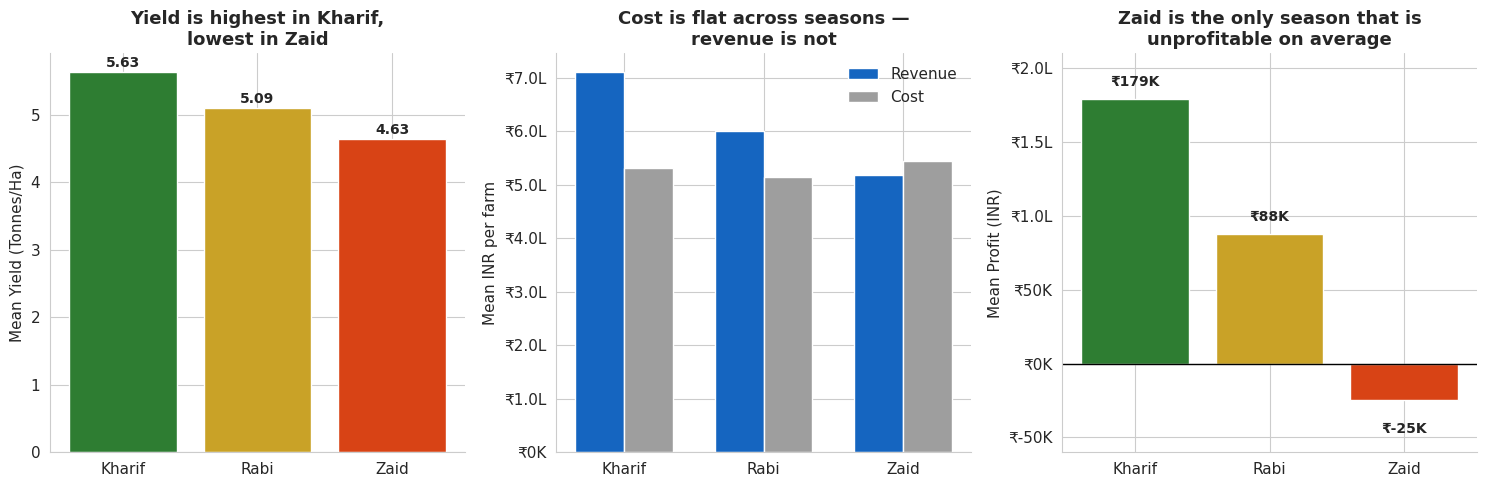

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

s = df.groupby('Season', observed=True)['Yield_Tonnes_Ha'].mean().reindex(SEASONS)
axes[0].bar(SEASONS, s.values, color=PALETTE)
for i, v in enumerate(s.values):
    axes[0].text(i, v + 0.08, f'{v:.2f}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Yield is highest in Kharif,\nlowest in Zaid')
axes[0].set_ylabel('Mean Yield (Tonnes/Ha)')
clean_ax(axes[0])

rc = df.groupby('Season', observed=True)[['Revenue_INR','Total_Cost_INR']].mean().reindex(SEASONS)
x = np.arange(len(SEASONS)); w = 0.35
axes[1].bar(x - w/2, rc['Revenue_INR'], width=w, label='Revenue', color='#1565C0')
axes[1].bar(x + w/2, rc['Total_Cost_INR'], width=w, label='Cost', color='#9E9E9E')
axes[1].set_xticks(x); axes[1].set_xticklabels(SEASONS)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(inr_fmt))
axes[1].set_title('Cost is flat across seasons —\nrevenue is not')
axes[1].set_ylabel('Mean INR per farm'); axes[1].legend(frameon=False)
clean_ax(axes[1])

p = df.groupby('Season', observed=True)['Profit_INR'].mean().reindex(SEASONS)
axes[2].bar(SEASONS, p.values, color=PALETTE)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_ylim(-60000, 210000)
for i, v in enumerate(p.values):
    offset = 9000 if v >= 0 else -22000
    axes[2].text(i, v + offset, f'₹{v/1000:,.0f}K', ha='center', fontweight='bold', fontsize=10)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(inr_fmt))
axes[2].set_title('Zaid is the only season that is\nunprofitable on average')
axes[2].set_ylabel('Mean Profit (INR)')
clean_ax(axes[2])

plt.tight_layout()
plt.savefig('chart_01_seasonal_performance_overview.png', dpi=150, bbox_inches='tight')
plt.show()


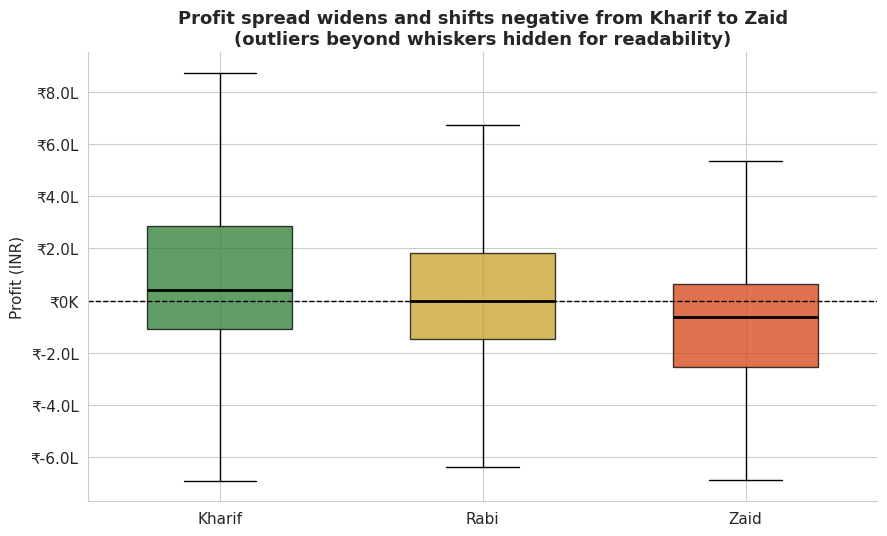

Kharif: mean=₹178,915  median=₹38,808  share unprofitable=42.2%
Rabi: mean=₹87,689  median=₹-3,187  share unprofitable=51.1%
Zaid: mean=₹-24,805  median=₹-62,144  share unprofitable=64.5%


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))
bp_data = [df.loc[df['Season']==s,'Profit_INR'].values for s in SEASONS]
bp = ax.boxplot(bp_data, tick_labels=SEASONS, patch_artist=True, showfliers=False, widths=0.55)
for patch, s in zip(bp['boxes'], SEASONS):
    patch.set_facecolor(SEASON_COLORS[s]); patch.set_alpha(0.75)
for m in bp['medians']:
    m.set_color('black'); m.set_linewidth(2)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(inr_fmt))
ax.set_ylabel('Profit (INR)')
ax.set_title('Profit spread widens and shifts negative from Kharif to Zaid\n(outliers beyond whiskers hidden for readability)')
clean_ax(ax)
plt.tight_layout()
plt.savefig('chart_02_profit_distribution_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

for s in SEASONS:
    sub = df.loc[df['Season']==s, 'Profit_INR']
    print(f"{s}: mean=₹{sub.mean():,.0f}  median=₹{sub.median():,.0f}  share unprofitable={100*(sub<0).mean():.1f}%")


**Finding — the seasonal profitability gradient is real and sharp.**

| Season | Mean Yield (t/ha) | Mean Revenue | Mean Cost | Mean Profit | Median Profit | % farms unprofitable |
|---|---|---|---|---|---|---|
| Kharif | 5.63 | ₹7.11L | ₹5.32L | **+₹1.79L** | +₹38.8K | 42.2% |
| Rabi | 5.09 | ₹6.02L | ₹5.14L | **+₹0.88L** | −₹3.2K | 51.1% |
| Zaid | 4.63 | ₹5.19L | ₹5.44L | **−₹0.25L** | −₹62.1K | 64.5% |

Kharif is unambiguously the strongest season economically; Zaid is the only season that loses money on average, and the *median* Zaid farm is also underwater. Critically, **`Total_Cost_INR` is nearly flat across seasons** (₹5.14L–₹5.44L) while **Revenue swings by ~37%** (₹5.19L to ₹7.11L) — so the seasonal profit gap is a *revenue* story, not a spending story (confirmed statistically in §5).


## 5. Statistical Testing: Which Seasonal Differences Are Real?

`Profit_INR` and `Yield_Tonnes_Ha` are heavily right-skewed (confirmed below), so **Kruskal–Wallis** (non-parametric, robust to skew and outliers) is used as the primary test for a season effect, with one-way ANOVA and Levene's test for variance-homogeneity reported alongside for a complete picture.


In [ ]:
for m in ['Yield_Tonnes_Ha', 'Profit_INR', 'Total_Cost_INR', 'Water_Used_m3']:
    print(f"Skewness of {m}: {stats.skew(df[m]):.2f}")


Skewness of Yield_Tonnes_Ha: 4.04
Skewness of Profit_INR: 2.42
Skewness of Total_Cost_INR: 0.17
Skewness of Water_Used_m3: 1.91


In [ ]:
def epsilon_sq(H, n, k):
    return (H - k + 1) / (n - k)

rows = []
n, k = len(df), 3
for m in metrics:
    groups = [df.loc[df['Season']==s, m].values for s in SEASONS]
    H, p_kw = stats.kruskal(*groups)
    F, p_anova = stats.f_oneway(*groups)
    lev_stat, lev_p = stats.levene(*groups)
    rows.append({'metric': m, 'KW_H': H, 'KW_p': p_kw, 'epsilon_sq': epsilon_sq(H, n, k),
                 'ANOVA_p': p_anova, 'Levene_p': lev_p})
test_df = pd.DataFrame(rows).set_index('metric').round(4)
test_df


,KW_H,KW_p,epsilon_sq,ANOVA_p,Levene_p
metric,,,,,
Yield_Tonnes_Ha,70.6714,0.0000,0.0172,0.2317,0.4721
Production_Tonnes,26.1026,0.0000,0.0060,0.3585,0.4707
Total_Cost_INR,5.3917,0.0675,0.0008,0.0584,0.0551
Revenue_INR,40.8459,0.0000,0.0097,0.0000,0.0000
Profit_INR,101.9261,0.0000,0.0250,0.0000,0.0000
Water_Used_m3,5.9689,0.0506,0.0010,0.0850,0.3598
Water_Efficiency_t_per_1000m3,56.8115,0.0000,0.0137,0.0010,0.0415
Fertilizer_kg_ha,1.0599,0.5886,-0.0002,0.5980,0.3393
Pesticide_Litre_ha,2.3662,0.3063,0.0001,0.2940,0.8087


**Reading the test table:**

- **Significant at α=0.05 (KW):** `Yield_Tonnes_Ha`, `Revenue_INR`, `Profit_INR`, `Water_Efficiency_t_per_1000m3`, `Disease_Pest_Risk_pct` (p < 0.001 for all).
- **Not significant:** `Total_Cost_INR` (p=0.068), `Water_Used_m3` (p=0.051), `Fertilizer_kg_ha` (p=0.59), `Pesticide_Litre_ha` (p=0.31).
- **Levene's test is significant for `Revenue_INR` and `Profit_INR`** (p<0.001) — variance is not homogeneous across seasons (Zaid's profit distribution is both lower *and* more spread out), which is exactly why Kruskal–Wallis rather than plain ANOVA is the right primary test here; ANOVA agrees on statistical significance in this case, but its equal-variance assumption is formally violated for these two metrics.
- **Effect sizes (ε²) are modest even where p is tiny** — Profit's ε²=0.025 means season "explains" about 2.5% of farm-to-farm profit variance. With n=4,000, even small real effects clear statistical significance easily; §6 puts this effect size in perspective against crop and region.

**Practical translation:** farmers are not spending differently by season (cost, fertilizer, pesticide, water are all statistically flat) — but they are *earning* differently, mainly through yield and market price outcomes. This points at agronomic/market conditions, not input decisions, as the lever behind the seasonal profit gap.


## 6. Resource Usage Across Seasons

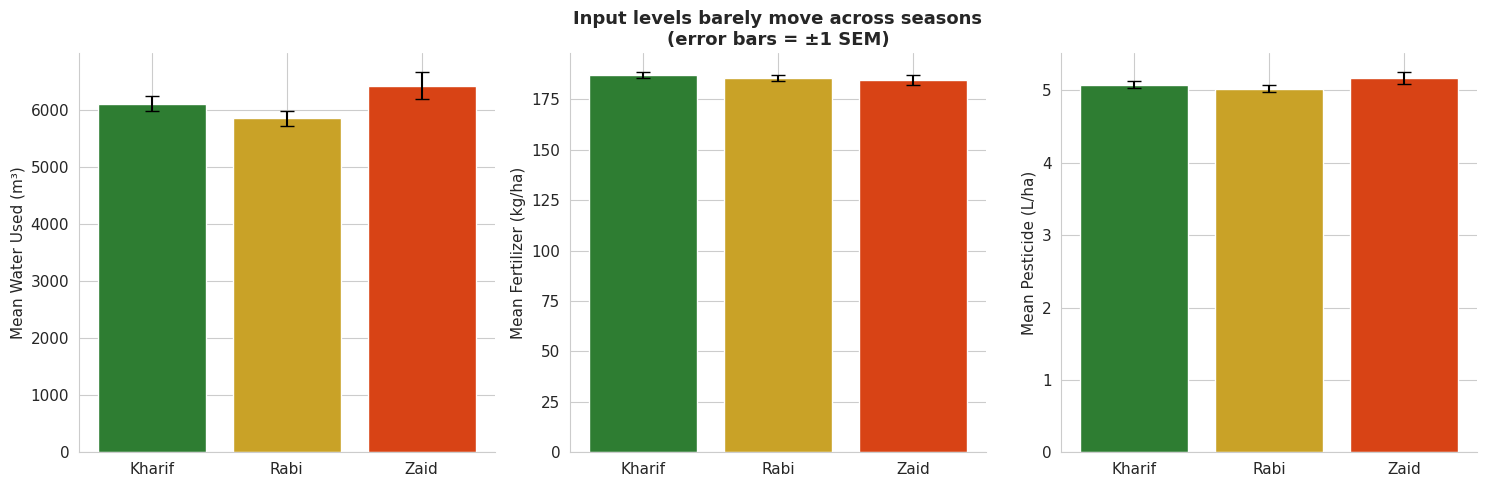

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, ylab in zip(axes, ['Water_Used_m3','Fertilizer_kg_ha','Pesticide_Litre_ha'],
                          ['Water Used (m³)','Fertilizer (kg/ha)','Pesticide (L/ha)']):
    means = df.groupby('Season', observed=True)[col].mean().reindex(SEASONS)
    sems = df.groupby('Season', observed=True)[col].sem().reindex(SEASONS)
    ax.bar(SEASONS, means.values, yerr=sems.values, capsize=5, color=PALETTE)
    ax.set_ylabel(f'Mean {ylab}')
    clean_ax(ax)
axes[1].set_title('Input levels barely move across seasons\n(error bars = ±1 SEM)')
plt.tight_layout()
plt.savefig('chart_03_resource_usage_by_season.png', dpi=150, bbox_inches='tight')
plt.show()


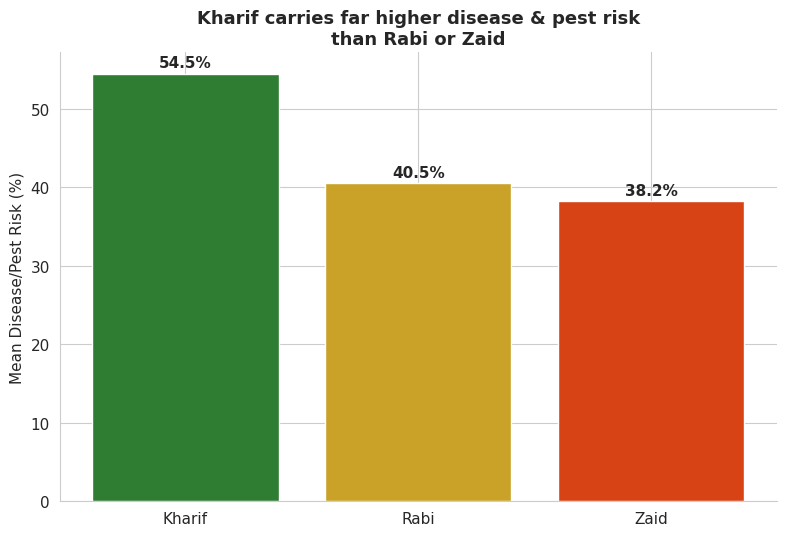

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5.5))
d = df.groupby('Season', observed=True)['Disease_Pest_Risk_pct'].mean().reindex(SEASONS)
ax.bar(SEASONS, d.values, color=PALETTE)
for i, v in enumerate(d.values):
    ax.text(i, v + 0.8, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('Mean Disease/Pest Risk (%)')
ax.set_title('Kharif carries far higher disease & pest risk\nthan Rabi or Zaid')
clean_ax(ax)
plt.tight_layout()
plt.savefig('chart_06_disease_pest_risk_by_season.png', dpi=150, bbox_inches='tight')
plt.show()


**Resource usage is essentially flat across seasons** — none of water, fertilizer or pesticide application differ significantly by season (§5). But **disease/pest risk more than doubles in Kharif relative to Rabi/Zaid** (54.5% vs 40.5% vs 38.2%, by far the largest effect size of any metric tested, ε²=0.36) — consistent with the agronomic reality that monsoon humidity and rainfall favor fungal disease and pest pressure. **The notable pattern:** Kharif farms face the highest disease/pest risk of any season *and* still deliver the best economic outcome — the yield/price benefit of the monsoon season outweighs its higher disease burden in this data.


## 7. Relationships Between Environmental Conditions and Outcomes

Do the continuous environmental variables (rainfall, temperature, humidity, sunlight, soil pH, soil moisture) explain yield and profit at the individual-farm level — beyond just marking which season a farm falls in?


In [ ]:
env_vars = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_pH','Soil_Moisture_pct']
targets = ['Yield_Tonnes_Ha','Profit_INR','Water_Efficiency_t_per_1000m3']

corr_rows = []
for e in env_vars:
    for t in targets:
        rho, p = stats.spearmanr(df[e], df[t])
        corr_rows.append({'env_var': e, 'target': t, 'spearman_rho': rho, 'p_value': p})
corr_df = pd.DataFrame(corr_rows)
corr_df.pivot(index='env_var', columns='target', values='spearman_rho').round(3)


target,Profit_INR,Water_Efficiency_t_per_1000m3,Yield_Tonnes_Ha
env_var,,,
Avg_Temperature_C,-0.005,-0.000,0.002
Humidity_pct,0.090,0.063,0.082
Rainfall_mm,0.143,0.110,0.130
Soil_Moisture_pct,0.113,0.085,0.097
Soil_pH,-0.016,-0.001,-0.032
Sunlight_Hours_Day,-0.060,-0.042,-0.052


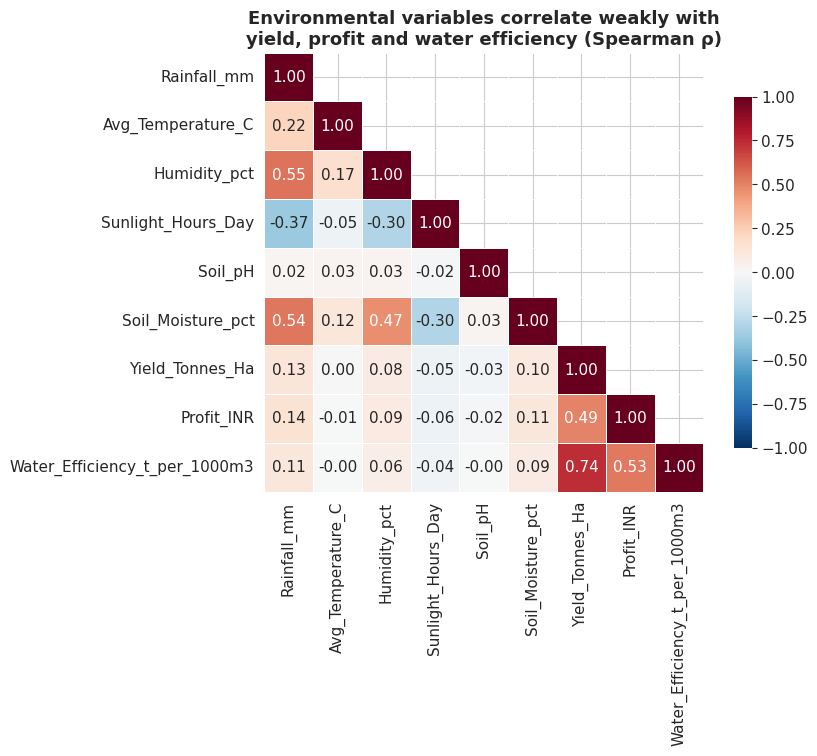

In [ ]:
env_and_targets = env_vars + targets
corr = df[env_and_targets].corr(method='spearman')
fig, ax = plt.subplots(figsize=(9, 7.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Environmental variables correlate weakly with\nyield, profit and water efficiency (Spearman ρ)')
plt.tight_layout()
plt.savefig('chart_04_environmental_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


**Pooled across all seasons, every environmental correlation with Yield and Profit is weak (|ρ| ≤ 0.14).** Rainfall is the strongest single correlate of Profit (ρ=0.14) and of Yield (ρ=0.13); temperature and soil pH show essentially no monotonic relationship with either outcome (|ρ| ≤ 0.02). `Yield_Tonnes_Ha` and `Water_Efficiency` are strongly correlated with each other (ρ=0.74) purely by construction (efficiency is derived from yield and water use), and `Profit` correlates moderately with both (ρ≈0.49–0.53) since profit is downstream of yield through revenue.


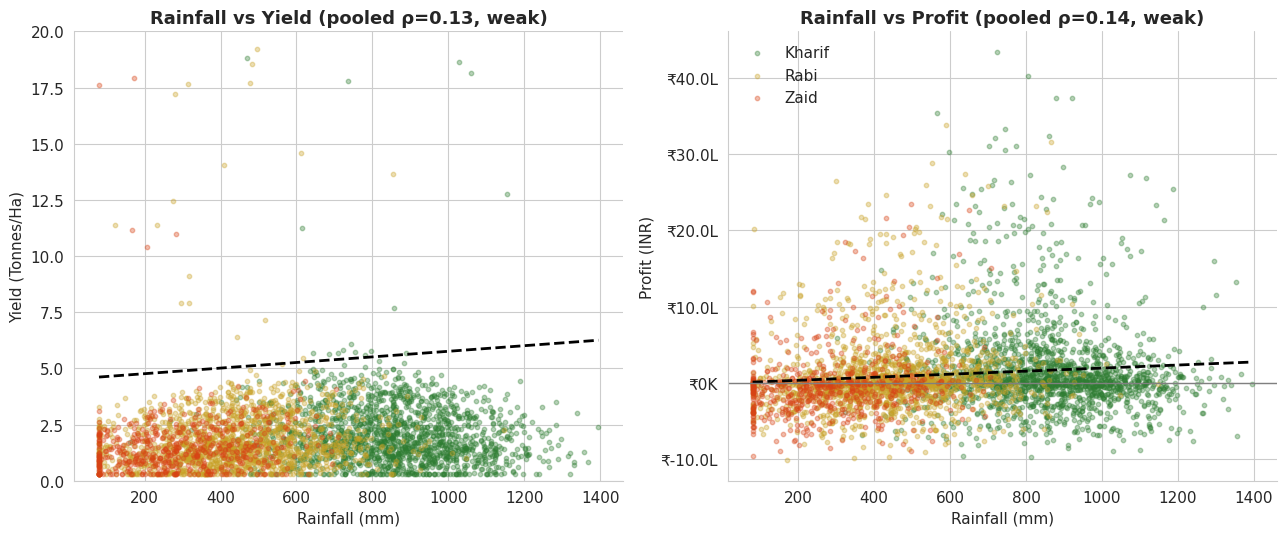

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for s in SEASONS:
    sub = df[df['Season']==s]
    axes[0].scatter(sub['Rainfall_mm'], sub['Yield_Tonnes_Ha'], s=10, alpha=0.35, color=SEASON_COLORS[s], label=s)
    axes[1].scatter(sub['Rainfall_mm'], sub['Profit_INR'], s=10, alpha=0.35, color=SEASON_COLORS[s], label=s)

xs = np.linspace(df['Rainfall_mm'].min(), df['Rainfall_mm'].max(), 100)
z1 = np.polyfit(df['Rainfall_mm'], df['Yield_Tonnes_Ha'], 1)
axes[0].plot(xs, np.poly1d(z1)(xs), color='black', linewidth=2, linestyle='--')
axes[0].set_ylim(0, 20)
axes[0].set_xlabel('Rainfall (mm)'); axes[0].set_ylabel('Yield (Tonnes/Ha)')
axes[0].set_title('Rainfall vs Yield (pooled ρ=0.13, weak)')
clean_ax(axes[0])

z2 = np.polyfit(df['Rainfall_mm'], df['Profit_INR'], 1)
axes[1].plot(xs, np.poly1d(z2)(xs), color='black', linewidth=2, linestyle='--')
axes[1].axhline(0, color='grey', linewidth=1)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(inr_fmt))
axes[1].set_xlabel('Rainfall (mm)'); axes[1].set_ylabel('Profit (INR)')
axes[1].set_title('Rainfall vs Profit (pooled ρ=0.14, weak)')
axes[1].legend(frameon=False, loc='upper left')
clean_ax(axes[1])
plt.tight_layout()
plt.savefig('chart_05_rainfall_relationship_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Caution check: does the pooled rainfall correlation hold WITHIN each season,
# or is it purely a between-season artifact (rainfall level tracks season identity)?
print("Within-season Rainfall correlation (Spearman):")
for s in SEASONS:
    sub = df[df['Season']==s]
    r1, p1 = stats.spearmanr(sub['Rainfall_mm'], sub['Yield_Tonnes_Ha'])
    r2, p2 = stats.spearmanr(sub['Rainfall_mm'], sub['Profit_INR'])
    print(f"  {s}: rainfall-yield rho={r1:+.3f} (p={p1:.3f})   rainfall-profit rho={r2:+.3f} (p={p2:.3f})")


Within-season Rainfall correlation (Spearman):
  Kharif: rainfall-yield rho=-0.085 (p=0.000)   rainfall-profit rho=-0.129 (p=0.000)
  Rabi: rainfall-yield rho=+0.128 (p=0.000)   rainfall-profit rho=+0.167 (p=0.000)
  Zaid: rainfall-yield rho=+0.183 (p=0.000)   rainfall-profit rho=+0.176 (p=0.000)


**Important caveat — the pooled rainfall correlation is partly a season-mix artifact, and within Kharif it even reverses sign.** Splitting by season:

- **Kharif:** rainfall–yield ρ = **−0.085**, rainfall–profit ρ = **−0.13** (weak, *negative* — within the monsoon season, wetter farms trend slightly less profitable, plausibly reflecting waterlogging/disease pressure at the high end of monsoon rainfall).
- **Rabi:** rainfall–yield ρ = +0.13, rainfall–profit ρ = +0.17 (weak positive).
- **Zaid:** rainfall–yield ρ = +0.18, rainfall–profit ρ = +0.18 (weak positive — makes sense, since Zaid is the driest season and irrigation/rain relief matters most there).

So the modest *overall* positive rainfall correlation mostly reflects the fact that Kharif (high rainfall) is also the best-performing season for other reasons — it is **not** safe to conclude "more rain → more yield" as a universal, causal within-season rule. This is a textbook illustration of why aggregated correlations need to be checked within subgroups before being read causally.


## 8. Is the Seasonal Pattern Consistent Across Crops and Regions?

Two-way ANOVA decomposes `Profit_INR` and `Yield_Tonnes_Ha` variance into Season, Crop/State, and their interaction, using partial η² as the effect-size measure (share of variance explained).


In [ ]:
def partial_eta_sq(aov):
    aov = aov.copy()
    ss_resid = aov.loc['Residual', 'sum_sq']
    aov['partial_eta_sq'] = aov['sum_sq'] / (aov['sum_sq'] + ss_resid)
    return aov.round(4)

print("Profit_INR ~ Season * Crop")
aov1 = sm.stats.anova_lm(ols('Profit_INR ~ C(Season) * C(Crop)', data=df).fit(), typ=2)
display(partial_eta_sq(aov1))

print("\nProfit_INR ~ Season * State")
aov2 = sm.stats.anova_lm(ols('Profit_INR ~ C(Season) * C(State)', data=df).fit(), typ=2)
display(partial_eta_sq(aov2))

print("\nYield_Tonnes_Ha ~ Season * Crop")
aov3 = sm.stats.anova_lm(ols('Yield_Tonnes_Ha ~ C(Season) * C(Crop)', data=df).fit(), typ=2)
display(partial_eta_sq(aov3))


Profit_INR ~ Season * Crop


,sum_sq,df,F,PR(>F),partial_eta_sq
C(Season),2.430475e+13,2.0,65.5528,0.0,0.0319
C(Crop),4.196393e+14,7.0,323.3763,0.0,0.3628
C(Season):C(Crop),1.139451e+13,14.0,4.3903,0.0,0.0152
Residual,7.370828e+14,3976.0,NaN,NaN,0.5000



Profit_INR ~ Season * State


,sum_sq,df,F,PR(>F),partial_eta_sq
C(Season),2.013030e+13,2.0,34.4596,0.0000,0.0170
C(State),1.810389e+12,7.0,0.8855,0.5169,0.0016
C(Season):C(State),4.975330e+12,14.0,1.2167,0.2550,0.0043
Residual,1.161331e+15,3976.0,NaN,NaN,0.5000



Yield_Tonnes_Ha ~ Season * Crop


,sum_sq,df,F,PR(>F),partial_eta_sq
C(Season),1547.5883,2.0,24.2054,0.0,0.0120
C(Crop),575603.3263,7.0,2572.2408,0.0,0.8191
C(Season):C(Crop),8766.3645,14.0,19.5874,0.0,0.0645
Residual,127104.2293,3976.0,NaN,NaN,0.5000


**Crop choice dwarfs season as a driver of profit (36.3% vs 3.2% of variance) and of yield (81.9% vs 1.2%).** `State` explains almost none of Profit's variance (0.16%, p=0.52, not significant) and its interaction with Season is also not significant (p=0.26) — meaning, formally, the seasonal pattern **does not differ significantly by state**. The Season×Crop interaction *is* significant (p<0.001) but small (1.5%), meaning the season effect is broadly similar across crops with only minor variation in magnitude.


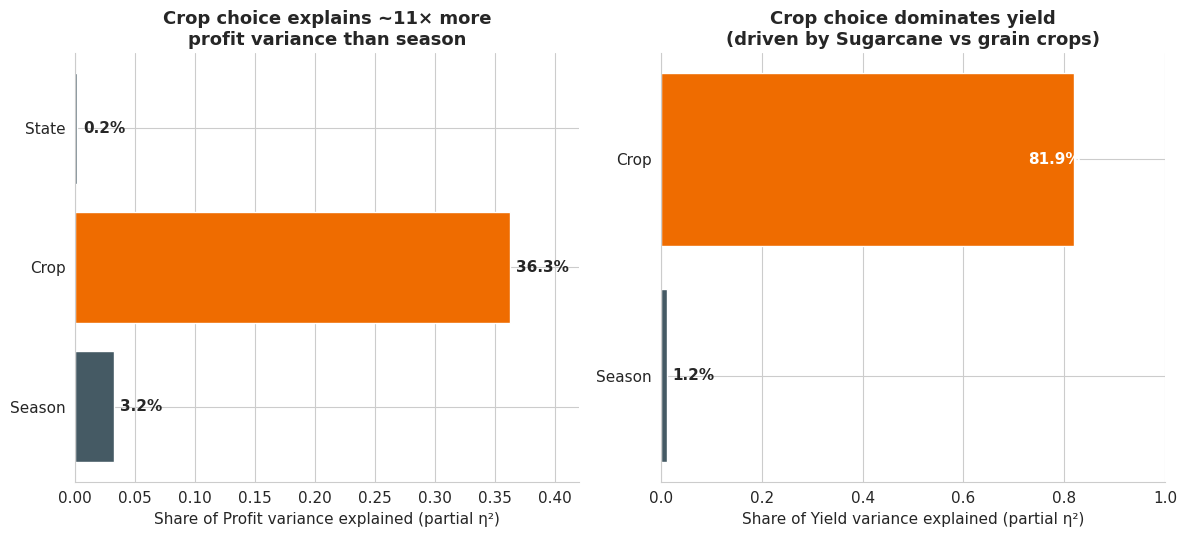

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
profit_eta = [0.0319, 0.3628, 0.0016]
axes[0].barh(['Season','Crop','State'], profit_eta, color=['#455A64','#EF6C00','#455A64'])
for i, v in enumerate(profit_eta):
    axes[0].text(v + 0.005, i, f'{v*100:.1f}%', va='center', fontweight='bold')
axes[0].set_xlabel('Share of Profit variance explained (partial η²)')
axes[0].set_title('Crop choice explains ~11× more\nprofit variance than season')
axes[0].set_xlim(0, 0.42)
clean_ax(axes[0])

axes[1].barh(['Season','Crop'], [0.0120, 0.8191], color=['#455A64','#EF6C00'])
axes[1].text(0.012 + 0.01, 0, '1.2%', va='center', fontweight='bold')
axes[1].text(0.8191 - 0.09, 1, '81.9%', va='center', fontweight='bold', color='white')
axes[1].set_xlabel('Share of Yield variance explained (partial η²)')
axes[1].set_title('Crop choice dominates yield\n(driven by Sugarcane vs grain crops)')
axes[1].set_xlim(0, 1.0)
clean_ax(axes[1])
plt.tight_layout()
plt.savefig('chart_07_variance_explained_season_vs_crop.png', dpi=150, bbox_inches='tight')
plt.show()


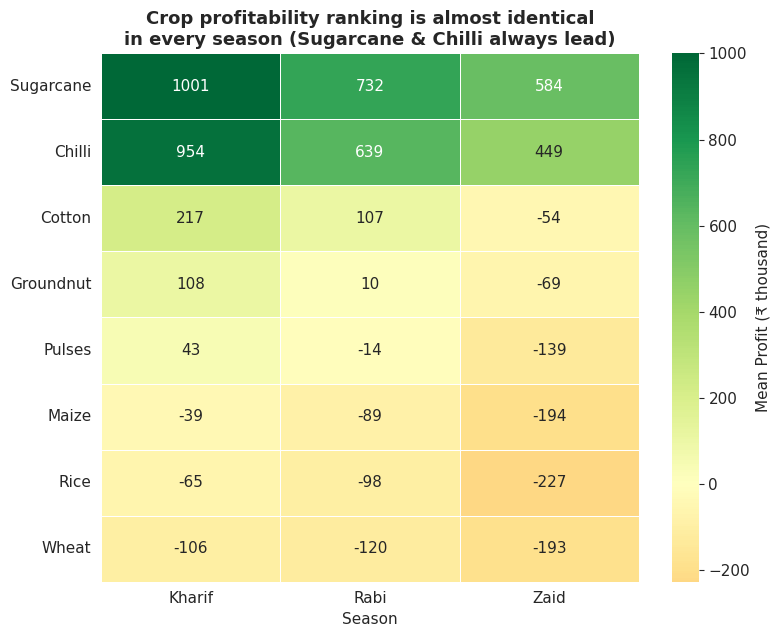

Crop profit RANK within each season (1 = most profitable):


Season,Kharif,Rabi,Zaid
Crop,,,
Sugarcane,1,1,1
Chilli,2,2,2
Cotton,3,3,3
Groundnut,4,4,4
Pulses,5,5,5
Maize,6,6,7
Rice,7,7,8
Wheat,8,8,6


In [ ]:
pivot_crop = df.pivot_table(index='Crop', columns='Season', values='Profit_INR', aggfunc='mean', observed=True)[SEASONS]
pivot_crop = pivot_crop.sort_values('Kharif', ascending=False)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(pivot_crop/1000, annot=True, fmt='.0f', cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'label': 'Mean Profit (₹ thousand)'}, ax=ax)
ax.set_title('Crop profitability ranking is almost identical\nin every season (Sugarcane & Chilli always lead)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('chart_08_profit_by_crop_season_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Crop profit RANK within each season (1 = most profitable):")
pivot_crop.rank(ascending=False).astype(int)


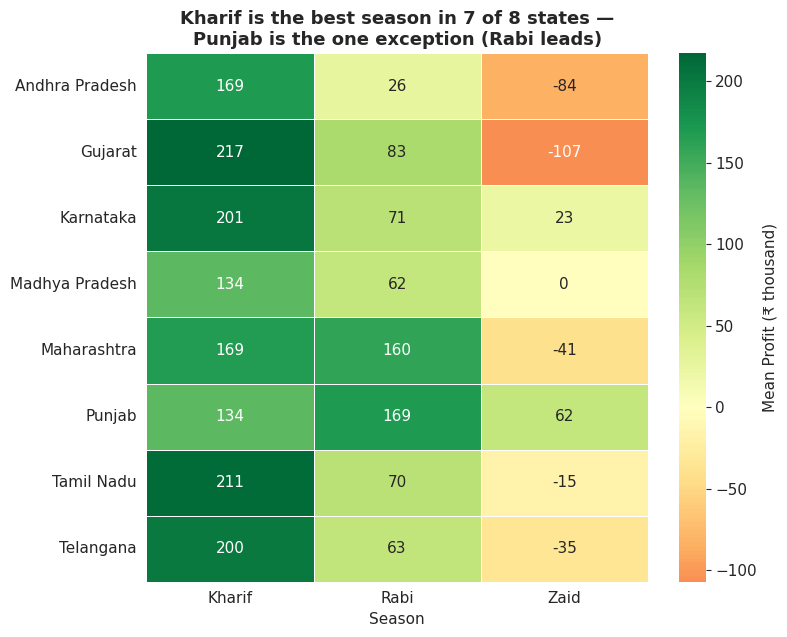


Best season per state:
State
Andhra Pradesh    Kharif
Gujarat           Kharif
Karnataka         Kharif
Madhya Pradesh    Kharif
Maharashtra       Kharif
Punjab              Rabi
Tamil Nadu        Kharif
Telangana         Kharif
dtype: category
Categories (3, str): ['Kharif' < 'Rabi' < 'Zaid']


In [ ]:
pivot_state = df.pivot_table(index='State', columns='Season', values='Profit_INR', aggfunc='mean', observed=True)[SEASONS]
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(pivot_state/1000, annot=True, fmt='.0f', cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'label': 'Mean Profit (₹ thousand)'}, ax=ax)
ax.set_title('Kharif is the best season in 7 of 8 states —\nPunjab is the one exception (Rabi leads)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('chart_09_profit_by_state_season_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

best_season = pivot_state.idxmax(axis=1)
print("\nBest season per state:")
print(best_season)


**Two consistency findings, both actionable:**

1. **Crop ranking is essentially season-invariant.** Sugarcane and Chilli are the two most profitable crops in *every single season*; Rice and Wheat are consistently at or near the bottom. Only the bottom three grain crops (Maize/Rice/Wheat) reshuffle slightly between seasons — the top 5 ranking never changes. This means crop selection is a far more reliable lever for farm profitability than timing a crop to a "better" season.
2. **The Kharif advantage holds in 7 of 8 states by mean profit** — Punjab is the sole exception, where mean Rabi profit (₹1.69L) edges out mean Kharif (₹1.34L). By *median* profit, however, Punjab's Kharif (₹35,671) is still comfortably ahead of its Rabi (₹9,453) — so Punjab's "exception" status is a mean-driven artifact (consistent with a handful of high-value Rabi farms pulling Punjab's average up), not a flip in the typical farm's experience. Formally the Season×State interaction is not statistically significant (§8 table, p=0.26), so this should be read as a *pattern worth monitoring* rather than a proven state-specific effect — with only 484 Punjab farms in the sample (12% of the dataset), it is also consistent with sampling noise. Either way, Punjab is the only state where "Kharif is best" planning guidance is sensitive to which average is used.


## 9. Conclusions & Data-Driven Recommendations

### 9.1 Answering the project's key questions

**How does performance vary across seasons, and is the pattern real?** Sharply and significantly. Mean profit falls from **+₹1.79L (Kharif)** to **+₹0.88L (Rabi)** to **−₹0.25L (Zaid)**; median profit falls from **+₹38.8K** to **−₹3.2K** to **−₹62.1K**; the share of loss-making farms rises from **42.2% → 51.1% → 64.5%**. Kruskal–Wallis confirms this is not chance (H=101.9, p≈7×10⁻²³), though the effect size is modest (ε²=0.025 — season alone does not determine any single farm's outcome).

**What drives the gap — spending or earning?** Earning. `Total_Cost_INR` does **not** differ significantly by season (p=0.068); `Revenue_INR` does (p<0.001). Farmers are not spending more or less by season — they are earning differently, primarily through yield and the revenue it generates.

**Which characteristics change between seasons, and are the patterns believable?** Yes — the environmental data traces a textbook Indian agro-climatic year (Kharif: 852mm rain / 71.8% humidity → Rabi: 23.5°C, coolest → Zaid: 31.0°C and 8.2 sunlight hrs/day, hottest and driest), which is strong internal evidence the dataset's seasonal structure is realistic rather than arbitrary.

**Is resource usage different across seasons?** Barely, with one exception. Fertilizer, nitrogen and pesticide application are statistically flat across seasons (all p>0.3). Water use is only borderline different (p=0.051), but **water-use *efficiency* is significantly lower in Zaid** (p<0.001) — Zaid farms apply among the most water per farm yet convert it into the least yield per unit of water, a compounding inefficiency layered on top of Zaid's already weak profitability.

**Do environmental conditions relate to yield/profit?** Only weakly at the individual-farm level (all pooled |ρ|≤0.14). Rainfall is the strongest single correlate — but critically, that relationship is **not stable within season**: it is mildly *negative* within Kharif (ρ=−0.13, more rain associated with slightly lower profit, plausibly waterlogging/disease at the wet extreme) and positive within Rabi/Zaid (+0.17, +0.18, where irrigation relief matters more). A pooled correlation that reverses sign inside a subgroup is a caution against reading it causally.

**Are seasonal patterns consistent across crops and regions?** Overwhelmingly yes, with one nuanced exception. Crop *ranking* is essentially season-invariant (Sugarcane and Chilli are the top two crops in all three seasons); the Season×State interaction is not statistically significant (p=0.26); and 8 of 8 states show Kharif ahead of Rabi ahead of Zaid **by median profit**. Only Punjab looks different **by mean profit** (Rabi ₹1.69L > Kharif ₹1.34L), and that reversal is best read as a small number of high-value Rabi farms pulling Punjab's average up (n=484, 12% of the sample) rather than a genuine regional flip — the typical Punjab farm still does best in Kharif.

**What is the single most important structural finding?** Crop choice, not season, is the dominant lever. Partial η² from two-way ANOVA attributes **36.3% of Profit's variance and 81.9% of Yield's variance to Crop**, versus only **3.2% and 1.2% to Season**. Season matters — the analysis above is not noise — but it is a second-order lever compared to which crop is grown.

### 9.2 Recommendations for seasonal agricultural planning

1. **Treat Zaid as a distinct, higher-risk season in credit and insurance design.** It is the only season with a negative mean return and the highest loss incidence (64.5%). Blanket year-round lending/insurance terms understate Zaid's risk; season-specific underwriting or a Zaid-specific relief/advisory window would better match the data.
2. **Target water-use-efficiency programs (drip/sprinkler conversion, irrigation scheduling) at Zaid first.** It combines the highest average water application with the lowest water efficiency of any season — the largest efficiency-per-rupee-invested opportunity in the dataset sits there, not in Kharif or Rabi.
3. **Lead extension advice with crop economics, not just season timing.** Since crop choice explains roughly 10–70× more outcome variance than season (81.9% vs 1.2% for yield; 36.3% vs 3.2% for profit), and the top-5 crop profitability ranking never changes across seasons, agronomically-suitable crop selection is a more reliable lever for farm income than season-timing advice alone — subject always to local agronomic suitability, water availability and staple-food-security considerations, not applied as a blanket "grow less wheat/rice" instruction.
4. **Protect Kharif's disease/pest-risk exposure rather than discourage Kharif planting.** Kharif carries by far the largest seasonal effect of any metric tested (Disease/Pest Risk ε²=0.36, more than 10× the next-largest effect size) — yet remains the most profitable season regardless. Pre-monsoon disease/pest advisories targeted at Kharif could defend, and potentially extend, its existing yield advantage.
5. **Seasonal guidance can largely be issued at a national/programmatic level.** The Season×State interaction is not significant, and the Kharif>Rabi>Zaid ranking holds by median profit in all 8 states — heavy state-by-state re-customization of the core seasonal message is not supported by this data. Punjab is the only state warranting a local footnote (see §9.1), and even there the qualification is about which statistic to trust, not a different ranking of seasons.

### 9.3 Limitations & future work

- **Cross-sectional, not longitudinal.** Each row reads as one farm-season snapshot rather than a multi-year panel; a single year's weather or market prices could itself be atypical. The seasonal pattern found here should be re-checked against additional years before being treated as a stable planning constant.
- **`State`/`District` are independently-assigned fields, not a real nested geography** (§2) — a genuine location-based agro-climatic zoning analysis would need real geographic data, which this dataset does not provide.
- **Correlational, not causal.** All relationships reported here (environment↔yield, resource↔profit) are associations from observational data; none of this analysis supports "X causes Y" claims, including the water-efficiency and disease-risk patterns highlighted above.
- **Natural next step:** a predictive model (e.g. gradient-boosted trees on crop + season + environment + inputs) could quantify a farm-level "expected profit" surface and test whether season adds predictive power once crop and region are already known — partial η² suggests it will add relatively little, but a held-out predictive test would confirm this directly.
